# Notebook 3: Teleconnection Analysis

This notebook investigates whether large scale climate modes can explain and predict compound wind hydro energy droughts in Patagonia:

1. Lag correlation analysis between climate modes (SAM, ONI, IOD) and WHDI
2. Seasonal stratification of teleconnections
3. Spatial composite mapping showing how climate modes affect the study region
4. SAM trend analysis and non stationarity implications

**Key finding from Notebook 2:** Wind and runoff anomalies are significantly  correlated in DJF (r=0.27) and MAM (r=0.35) but not in JJA/SON. Compound droughts occur 1.81× more often than random chance. This suggests a shared climate driver active in summer/autumn and this notebook identifies that driver.

## Imports and loading

In [27]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
import os
import warnings
import cartopy.crs as ccrs
import cartopy.feature as cfeature

df = pd.read_csv(
    "../data/processed/whdi_timeseries.csv", index_col="date", parse_dates=True
)

spatial_path = "../data/processed/era5_masked_spatial.nc"
file_size_mb = os.path.getsize(spatial_path) / (1024 * 1024)
print(f"Spatial file size: {file_size_mb:.1f} MB")

# Load spatial ERA5 for the maps
ds = xr.open_dataset("../data/processed/era5_masked_spatial.nc")

print(f"Timeseries data: {df.shape}")
print(f"Period: {df.index[0]}-{df.index[-1]}")
print(f"Columns: {list(df.columns)}")
print(f"Spatial data variables: {list(ds.data_vars)}")

SEASONS = ["DJF", "MAM", "JJA", "SON"]

Spatial file size: 27.6 MB
Timeseries data: (564, 13)
Period: 1979-01-01 00:00:00-2025-12-01 00:00:00
Columns: ['wind_speed', 'temperature', 'precipitation', 'runoff', 'snowmelt', 'sam', 'oni', 'iod', 'wind_std', 'runoff_std', 'whdi_1', 'whdi_3', 'whdi_6']
Spatial data variables: ['wind_speed', 'temperature', 'precipitation', 'runoff', 'snowmelt']


## Creating effective degrees of freedom function

With 564 monthly observations, even a tiny correlation (r=0.08) would appear significant at p<0.05 using the raw sample size. But consecutive months are not independent, a positive SAM in January is likely followed by positive SAM in February. The effective degrees of freedom correction accounts for this autocorrelation, giving honest significance tests.

The difference can be dramatic. If both series have lag1 autocorrelation of 0.5, effective n drops from 564 to roughly 188. A correlation that looked significant at n=564 might not be at n=188.

In [28]:
def effective_n(x, y):
    """
    Compute effective degrees of freedom for correlation significance testing.

    Formula: n_eff = n * (1 - r1_x * r1_y) / (1 + r1_x * r1_y) where r1_x and r1_y are the lag1 autocorrelations of x and y.
    """
    n = len(x)

    # lag1 autocorrelation for each series
    r1_x = pd.Series(x).autocorr(lag=1)
    r1_y = pd.Series(y).autocorr(lag=1)

    # Handle nan autocorrelation
    if np.isnan(r1_x) or np.isnan(r1_y):
        return n

    n_eff = n * (1 - (r1_x * r1_y)) / (1 + (r1_x * r1_y))

    return max(int(n_eff), 3)


def correlation_with_significance(x, y):
    """
    Compute Pearson correlation with significance adjusted for autocorrelation.

    Returns correlation coefficient, raw p-value, adjusted p-value, and effective sample size.
    """
    # Remove nan pairs
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = np.array(x)[mask]
    y_clean = np.array(y)[mask]

    if len(x_clean) < 4:
        return np.nan, np.nan, np.nan, 0

    # Correlation
    r, p_raw = stats.pearsonr(x_clean, y_clean)

    # Adjusted significance using effective degrees of freedom
    n_eff = effective_n(x_clean, y_clean)

    # Recompute p value with effective degrees of freedom
    # t statistic for correlaton
    if abs(r) >= 1.0:
        p_adj = 0.0
    else:
        t_stat = r * np.sqrt((n_eff - 2) / (1 - r**2))
        p_adj = 2 * stats.t.sf(abs(t_stat), df=n_eff - 2)

    return r, p_raw, p_adj, n_eff

## Lag Correlation Analysis

For each climate mode, compute correlation with WHDI at lags 0-12 months:
- Positive lag means climate mode LEADS the WHDI 

In [29]:
max_lag = 12
climate_modes = ["sam", "oni", "iod"]
target_vars = ["whdi_1", "whdi_3", "whdi_6", "wind_std", "runoff_std"]

lag_results = []

for mode in climate_modes:
    for target in target_vars:
        for lag in range(0, max_lag + 1):
            # Shift the climate mode backwards by lag months
            # does it the mode at time t correlate with the target at time t + lag
            mode_series = df[mode].values[:-lag] if lag > 0 else df[mode].values
            target_series = df[target].values[lag:] if lag > 0 else df[target].values

            r, p_raw, p_adj, n_eff = correlation_with_significance(
                mode_series, target_series
            )

            lag_results.append(
                {
                    "climate_mode": mode,
                    "target": target,
                    "lag_months": lag,
                    "correlation": r,
                    "p_raw": p_raw,
                    "p_adjusted": p_adj,
                    "n_effective": n_eff,
                    "significant_raw": p_raw < 0.05 if not np.isnan(p_raw) else False,
                    "significant_adj": p_adj < 0.05 if not np.isnan(p_adj) else False,
                }
            )

df_lags = pd.DataFrame(lag_results)

print(" " * 19 + "Strongest Correlations (adjusted p < 0.05)")
print("=" * 80)
sig_results = df_lags[df_lags["significant_adj"]].copy()
if len(sig_results) > 0:
    for mode in climate_modes:
        mode_sig = sig_results[sig_results["climate_mode"] == mode]
        if len(mode_sig) > 0:
            best = mode_sig.loc[mode_sig["correlation"].abs().idxmax()]
            print(f"\n{mode.upper()}")
            print(
                f"    Strongest: r={best['correlation']:.3f} with {best['target']} at lag {best['lag_months']} months (p_adj={best['p_adjusted']:.4f})"
            )
            print(f"    Total significant correlation: {len(mode_sig)}")
        else:
            print(f"\n{mode.upper()}: No significant correlation after adjustment")
else:
    print("No significant correlations found after autocorrelation adjustment.")
    print("This may indicate that climate modes don't predict compound droughts.")

df_lags.to_csv("../results/tables/lag_correlations.csv", index=False)

                   Strongest Correlations (adjusted p < 0.05)

SAM
    Strongest: r=-0.203 with whdi_6 at lag 3 months (p_adj=0.0001)
    Total significant correlation: 24

ONI
    Strongest: r=0.229 with runoff_std at lag 0 months (p_adj=0.0007)
    Total significant correlation: 9

IOD
    Strongest: r=-0.287 with runoff_std at lag 10 months (p_adj=0.0000)
    Total significant correlation: 25


### Climate mode further investigation


In [30]:
print(" " * 20 + "Full Lag Structure for All Modes to WHDI3")
print("=" * 81)

for mode in ["sam", "oni", "iod"]:
    subset = df_lags[
        (df_lags["climate_mode"] == mode) & (df_lags["target"] == "whdi_3")
    ].sort_values("lag_months")

    print(f"\n  {mode.upper()} to WHDI3:")
    for _, row in subset.iterrows():
        sig = "**" if row["significant_adj"] else "  "
        bar = "|" * int(abs(row["correlation"]) * 50)
        sign = "+" if row["correlation"] > 0 else "-"
        print(
            f"    Lag {row['lag_months']:2d}: r={row['correlation']:+.3f} {sig} {sign}{bar}"
        )

# Same for individual components
print(" " * 25 + "\nComponent Breakdown:")
print("=" * 70)

for mode in ["oni", "iod"]:
    for target in ["wind_std", "runoff_std"]:
        subset = df_lags[
            (df_lags["climate_mode"] == mode) & (df_lags["target"] == target)
        ].sort_values("lag_months")

        print(f"\n  {mode.upper()} to {target}:")
        for _, row in subset.iterrows():
            sig = "**" if row["significant_adj"] else "  "
            bar = "|" * int(abs(row["correlation"]) * 50)
            sign = "+" if row["correlation"] > 0 else "-"
            print(
                f"    Lag {row['lag_months']:2d}: r={row['correlation']:+.3f} {sig} {sign}{bar}"
            )

# Cross correlation between climate indices
print("\n\nInter-Index Correlations:")
print("=" * 70)

for mode_a, mode_b in [("sam", "oni"), ("sam", "iod"), ("oni", "iod")]:
    series_a = df[mode_a].dropna()
    series_b = df[mode_b].dropna()

    # Align
    common_idx = series_a.index.intersection(series_b.index)
    a = series_a.loc[common_idx]
    b = series_b.loc[common_idx]

    r, p = stats.pearsonr(a, b)
    print(f"  {mode_a.upper()} vs {mode_b.upper()}: r={r:.3f}, p={p:.4f}")

# Also check lagged cross-correlations between IOD and ONI
print("\n  IOD/ONI Lag Structure (IOD leads ONI):")
for lag in range(0, 13):
    iod_vals = df["iod"].values[:-lag] if lag > 0 else df["iod"].values
    oni_vals = df["oni"].values[lag:] if lag > 0 else df["oni"].values

    mask = ~(np.isnan(iod_vals) | np.isnan(oni_vals))
    if mask.sum() > 10:
        r, p = stats.pearsonr(iod_vals[mask], oni_vals[mask])
        sig = "**" if p < 0.05 else "  "
        print(f"    Lag {lag:2d}: r={r:+.3f} {sig}")

                    Full Lag Structure for All Modes to WHDI3

  SAM to WHDI3:
    Lag  0: r=-0.140 ** -||||||
    Lag  1: r=-0.174 ** -||||||||
    Lag  2: r=-0.198 ** -|||||||||
    Lag  3: r=-0.175 ** -||||||||
    Lag  4: r=-0.139 ** -||||||
    Lag  5: r=-0.119 ** -|||||
    Lag  6: r=-0.051    -||
    Lag  7: r=-0.026    -|
    Lag  8: r=-0.023    -|
    Lag  9: r=-0.057    -||
    Lag 10: r=-0.058    -||
    Lag 11: r=-0.006    -
    Lag 12: r=+0.007    +

  ONI to WHDI3:
    Lag  0: r=+0.237    +|||||||||||
    Lag  1: r=+0.184    +|||||||||
    Lag  2: r=+0.122    +||||||
    Lag  3: r=+0.056    +||
    Lag  4: r=-0.007    -
    Lag  5: r=-0.060    -||
    Lag  6: r=-0.096    -||||
    Lag  7: r=-0.116    -|||||
    Lag  8: r=-0.124    -||||||
    Lag  9: r=-0.129    -||||||
    Lag 10: r=-0.138    -||||||
    Lag 11: r=-0.150    -|||||||
    Lag 12: r=-0.160    -|||||||

  IOD to WHDI3:
    Lag  0: r=+0.071    +|||
    Lag  1: r=+0.049    +||
    Lag  2: r=+0.013    +
    Lag

#### Summary

**SAM is the primary compound driver.** Clean negative correlations with WHDI3 from lag 0 to lag 5, peaking at lag 2 (r=-0.198). Signal is coherent building smoothly, peaking, and then decaying. Affects both wind and runoff components, confirming it as the shared driver suggested by Notebook 2's seasonal correlation structure.

**ONI is hydro specific with no useful lead time.** Zero effect on wind at any lag. Positive correlation with runoff at lag 0-1 (El Niño = more runoff now), then negative at lags 9-12 (reflecting the La Niña phase that follows). The concurrent signal provides no forecast value; the long lag signal is indirect.

**IOD is an ENSO early warning system for hydro.** Strongest predictor of runoff at long lead times (r=-0.287 at lag 10). This is not a direct teleconnection. IOD/ONI cross correlations confirm that positive IOD today predicts La Niña conditions 10-12 months later (r=-0.24 at lag 12), which in turn reduces Patagonian precipitation and runoff. IOD therefore provides 8-12 months of lead time for the hydro component, longer than any other mode.

**Neither ONI nor IOD affects the wind component.** Wind variability in northern Patagonia is controlled by SAM only.

### Lag Correlation Plots

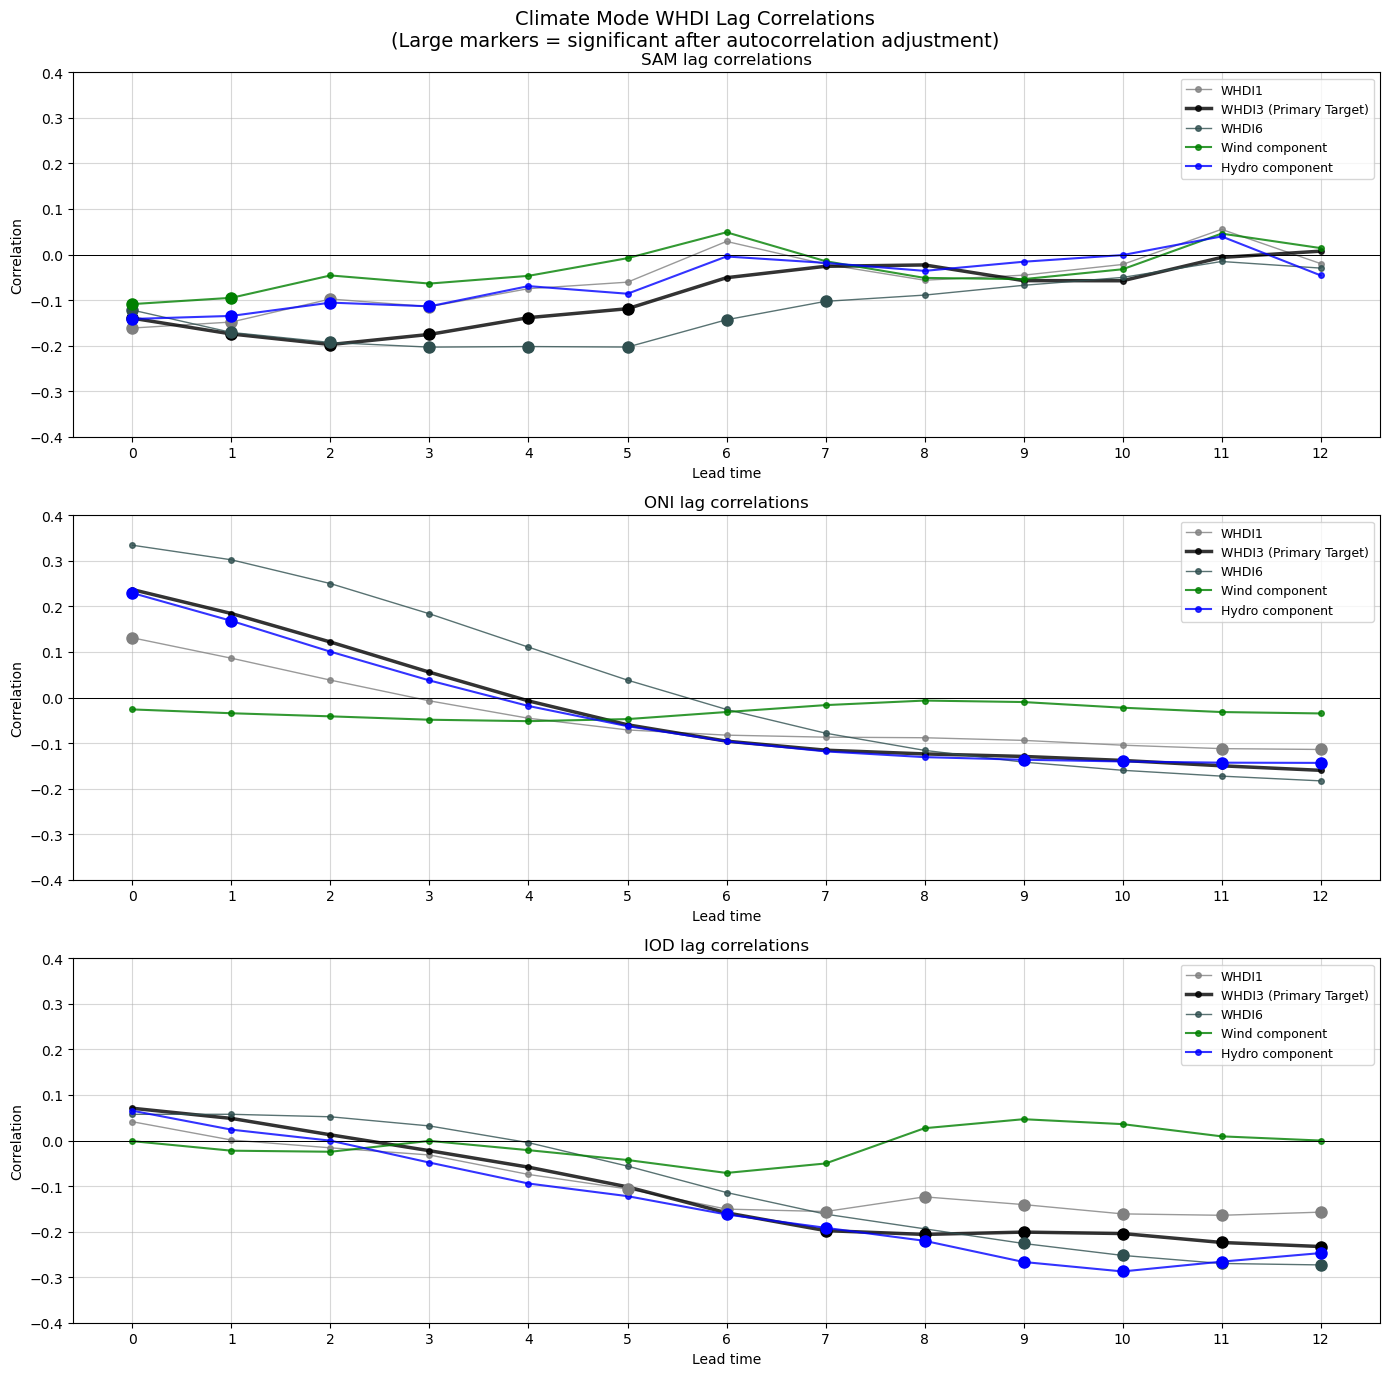

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

target_colors = {
    "whdi_1": ("grey", 1.0, "WHDI1"),
    "whdi_3": ("black", 2.5, "WHDI3 (Primary Target)"),
    "whdi_6": ("darkslategrey", 1.0, "WHDI6"),
    "wind_std": ("green", 1.5, "Wind component"),
    "runoff_std": ("blue", 1.5, "Hydro component"),
}

for ax, mode in zip(axes, climate_modes):
    for target, (color, linewidth, label) in target_colors.items():
        subset = df_lags[
            (df_lags["climate_mode"] == mode) & (df_lags["target"] == target)
        ]
        correlations = subset["correlation"].values
        significant = subset["significant_adj"].values
        lags = subset["lag_months"].values

        ax.plot(
            lags,
            correlations,
            "o-",
            color=color,
            linewidth=linewidth,
            markersize=4,
            label=label,
            alpha=0.8,
        )

        # Mark significant points with a marker
        sig_mask = significant
        if sig_mask.any():
            ax.plot(
                lags[sig_mask],
                correlations[sig_mask],
                "o",
                color=color,
                markersize=8,
                zorder=5,
            )

        ax.axhline(y=0, color="black", linewidth=0.5)
        ax.set_title(f"{mode.upper()} lag correlations", fontsize=12)
        ax.set_ylabel("Correlation")
        ax.set_xlabel("Lead time")
        ax.set_xticks(range(0, max_lag + 1))
        ax.legend(loc="best", fontsize=9)
        ax.grid(True, alpha=0.5)
        ax.set_ylim(-0.4, 0.4)

plt.suptitle(
    "Climate Mode WHDI Lag Correlations\n(Large markers = significant after autocorrelation adjustment)",
    fontsize=14,
)
plt.tight_layout()
plt.savefig("../results/figures/lag_correlations.png", dpi=200, bbox_inches="tight")
plt.show()

### Seasonal Stratification

I repeat lag correlation analysis for each season separately. This is critical because SAM's influence, and the other climate modes, vary dramatically by season.

In [32]:
season_map = {
    1: "DJF",
    2: "DJF",
    3: "MAM",
    4: "MAM",
    5: "MAM",
    6: "JJA",
    7: "JJA",
    8: "JJA",
    9: "SON",
    10: "SON",
    11: "SON",
    12: "DJF",
}

df["season"] = df.index.month.map(season_map)

seasonal_results = []

for season in SEASONS:
    season_data = df[df["season"] == season]

    for mode in climate_modes:
        for target in ["whdi_3", "wind_std", "runoff_std"]:
            for lag in range(0, max_lag + 1):
                mode_values = (
                    season_data[mode].values[:-lag]
                    if lag > 0
                    else season_data[mode].values
                )
                target_values = (
                    season_data[target].values[lag:]
                    if lag > 0
                    else season_data[target].values
                )

                r, p_raw, p_adj, n_eff = correlation_with_significance(
                    mode_values, target_values
                )

                seasonal_results.append(
                    {
                        "season": season,
                        "climate_mode": mode,
                        "target": target,
                        "lag_months": lag,
                        "correlation": r,
                        "p_adjusted": p_adj,
                        "n_effective": n_eff,
                        "significant": p_adj < 0.05 if not np.isnan(p_adj) else False,
                    }
                )

df_seasonal = pd.DataFrame(seasonal_results)
df_seasonal.to_csv("../results/tables/seasonal_lag_correlations.csv", index=False)

# Print significant results by season
print(" " * 15 + "Significant Seasonal Teleconnections (p_adj < 0.05)")
print("=" * 81)
for season in SEASONS:
    sig = df_seasonal[(df_seasonal["season"] == season) & (df_seasonal["significant"])]
    print(f"\n{season}: {len(sig)} significant correlations")
    if len(sig) > 0:
        for _, row in sig.iterrows():
            print(
                f"    {row['climate_mode'].upper()} to {row['target']}: r={row['correlation']:.3f} at lag {row['lag_months']}m (n_eff={row['n_effective']})"
            )

               Significant Seasonal Teleconnections (p_adj < 0.05)

DJF: 10 significant correlations
    SAM to whdi_3: r=-0.299 at lag 0m (n_eff=103)
    SAM to whdi_3: r=-0.255 at lag 1m (n_eff=102)
    SAM to wind_std: r=-0.213 at lag 0m (n_eff=141)
    SAM to runoff_std: r=-0.300 at lag 0m (n_eff=111)
    SAM to runoff_std: r=-0.274 at lag 1m (n_eff=110)
    IOD to whdi_3: r=-0.247 at lag 5m (n_eff=72)
    IOD to whdi_3: r=-0.240 at lag 6m (n_eff=76)
    IOD to wind_std: r=-0.196 at lag 2m (n_eff=138)
    IOD to wind_std: r=-0.215 at lag 12m (n_eff=128)
    IOD to runoff_std: r=0.250 at lag 9m (n_eff=83)

MAM: 4 significant correlations
    SAM to whdi_3: r=-0.224 at lag 0m (n_eff=121)
    SAM to runoff_std: r=-0.305 at lag 0m (n_eff=133)
    ONI to wind_std: r=-0.230 at lag 2m (n_eff=115)
    IOD to runoff_std: r=-0.210 at lag 2m (n_eff=111)

JJA: 15 significant correlations
    SAM to wind_std: r=0.171 at lag 2m (n_eff=135)
    ONI to whdi_3: r=0.348 at lag 0m (n_eff=70)
    ONI 

### Seasonal Teleconnection Heatmap

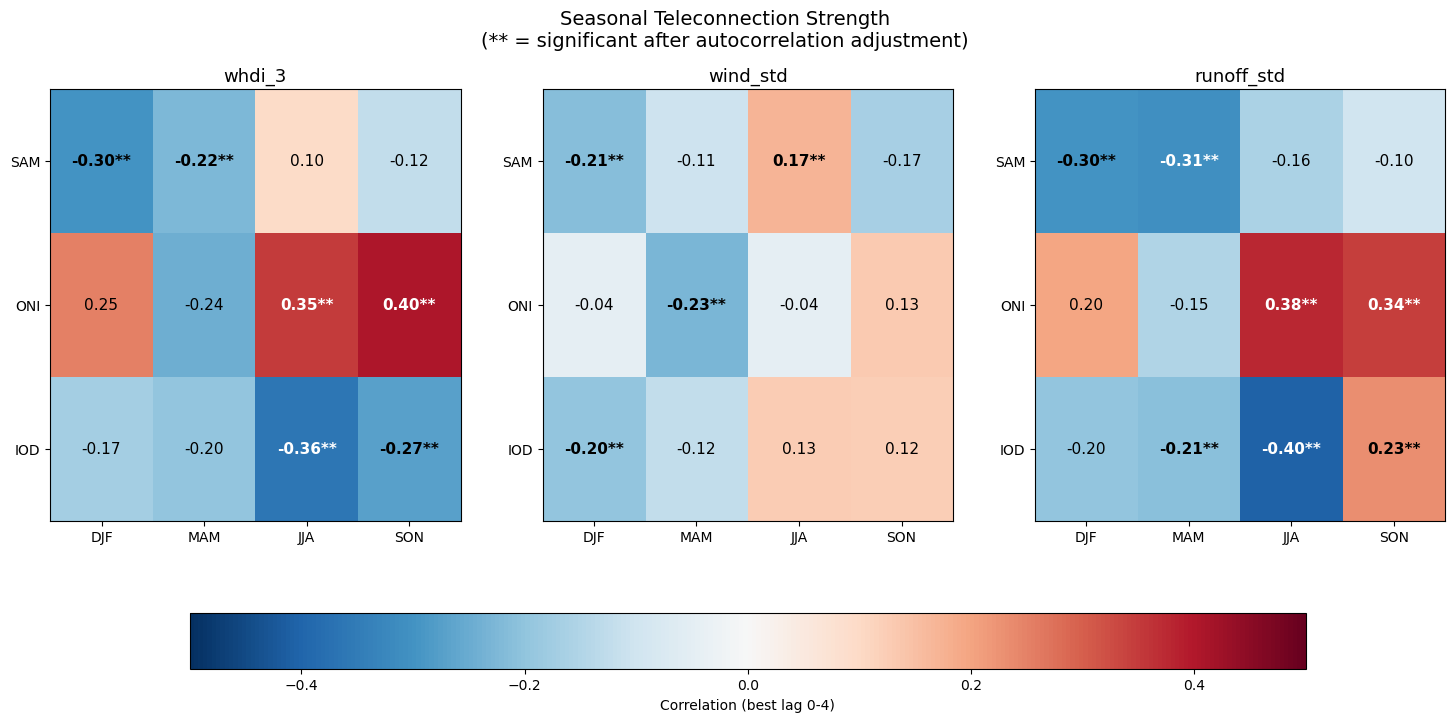

In [33]:
# Create a summary heatmap: mode × season for WHDI3 at the optimal lag
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, target in zip(axes, ["whdi_3", "wind_std", "runoff_std"]):
    # For each mode × season, find the strongest correlation at any lag 0-4
    heatmap_data = np.zeros((len(climate_modes), 4))
    sig_mask = np.zeros((len(climate_modes), 4), dtype=bool)

    for i, mode in enumerate(climate_modes):
        for j, season in enumerate(SEASONS):
            subset = df_seasonal[
                (df_seasonal["climate_mode"] == mode)
                & (df_seasonal["season"] == season)
                & (df_seasonal["target"] == target)
                & (df_seasonal["lag_months"] < 4)
            ]

            if len(subset) > 0:
                # Take the correlation with the largest absolute value
                best_idx = subset["correlation"].abs().idxmax()
                heatmap_data[i, j] = subset.loc[best_idx, "correlation"]
                sig_mask[i, j] = subset.loc[best_idx, "significant"]

    im = ax.imshow(heatmap_data, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")

    for i in range(len(climate_modes)):
        for j in range(4):
            val = heatmap_data[i, j]
            sig = "**" if sig_mask[i, j] else ""
            color = "white" if abs(val) > 0.3 else "black"
            ax.text(
                j,
                i,
                f"{val:.2f}{sig}",
                ha="center",
                va="center",
                fontsize=11,
                color=color,
                fontweight="bold" if sig else "normal",
            )

    ax.set_xticks(range(4))
    ax.set_xticklabels(SEASONS)
    ax.set_yticks(range(len(climate_modes)))
    ax.set_yticklabels([m.upper() for m in climate_modes])
    ax.set_title(f"{target}", fontsize=13)

plt.colorbar(
    im,
    ax=axes,
    label="Correlation (best lag 0-4)",
    shrink=0.8,
    orientation="horizontal",
)
plt.suptitle(
    "Seasonal Teleconnection Strength\n(** = significant after autocorrelation adjustment)",
    fontsize=14,
)
plt.savefig(
    "../results/figures/seasonal_teleconnection_heatmap.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

## Composite Analysis

Composite analysis: how does the spatial pattern of wind and runoff differ during positive vs negative phases of each climate mode? 

### Setup

In [ ]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # Monthly climatology for each grid cell
    spatial_clim = ds.groupby("time.month").mean(dim="time")
    spatial_std = ds.groupby("time.month").std(dim="time")

    ds_anom = ds.copy()
    for month in range(1, 13):
        month_mask = ds.time.dt.month == month
        for var in ds.data_vars:
            ds_anom[var].loc[{"time": month_mask}] = ds[var].sel(
                time=month_mask
            ) - spatial_clim[var].sel(month=month) / spatial_std[var].sel(month=month)

    # Drop month coordinate if it exists
    if "month" in ds_anom.coords:
        ds_anom = ds_anom.drop_vars("month")

print("Anomaly dataset computed")
print(f"Variables: {list(ds_anom.data_vars)}")

Anomaly dataset computed
Variables: ['wind_speed', 'temperature', 'precipitation', 'runoff', 'snowmelt']


In [39]:
def get_composite_months(index_series, threshold_std=0.75):
    """
    Identify positive and negative phase months for a climate mode.

    Positive phase: index > threshold_std standard deviations above mean
    Negative phase: index < threshold_std standard deviations below mean

    Returns boolean arrays aligned with the index timeseries.
    """
    mean = index_series.mean()
    std = index_series.std()

    positive = index_series > (mean + threshold_std * std)
    negative = index_series < (mean - threshold_std * std)

    return positive, negative


def get_seasonal_mask(df, months):
    """Return the boolean mask for specific months"""
    return df.index.month.isin(months)


season_months = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

composite_figs = [
    {
        "mode": "sam",
        "season": "DJF",
        "title": "SAM in DJF (compound driver)",
        "justification": "SAM drives both wind (r=-0.21) and runoff (r=-0.30) in summer",
    },
    {
        "mode": "oni",
        "season": "SON",
        "title": "ONI in SON (Concurrent Runoff)",
        "justification": "ONI-runoff in SON (r=0.34) strongest ONI signal",
    },
    {
        "mode": "iod",
        "season": "JJA",
        "title": "IOD in JJA (Strongest Teleconnection)",
        "justification": "IOD runoff in JJA (r=-0.40) is the strongest signal found",
    },
]

# Compute composites for each climate mode
composites = {}
for config in composite_figs:
    mode = config["mode"]
    season = config["season"]
    key = f"{mode}_{season}"

    # Filter to season
    season_mask = get_seasonal_mask(df, season_months[season])
    season_df = df[season_mask]

    # Positive/Negative months within the season
    pos, neg = get_composite_months(season_df[mode])

    composites[key] = {
        "positive": pos,
        "negative": neg,
        "config": config,
    }

    print(f"{mode.upper()} in {season}:")
    print(f"    Positive months: {pos.sum()} months")
    print(f"    Negative months: {neg.sum()} months")
    print(f"    Justification: {config['justification']}")

print("\n")
for mode in ["sam", "oni", "iod"]:
    series = df[mode].dropna()
    mean = series.mean()
    std = series.std()
    pos_threshold = mean + 0.75 * std
    neg_threshold = mean - 0.75 * std

    print(f"{mode.upper()}:")
    print(f"  Mean: {mean:.3f}, Std: {std:.3f}")
    print(f"  Positive threshold: > {pos_threshold:.3f}")
    print(f"  Negative threshold: < {neg_threshold:.3f}")
    print(f"  Values above pos: {(series > pos_threshold).sum()}")
    print(f"  Values below neg: {(series < neg_threshold).sum()}")
    print(f"  Neutral: {((series >= neg_threshold) & (series <= pos_threshold)).sum()}")
    print()

SAM in DJF:
    Positive months: 37 months
    Negative months: 34 months
    Justification: SAM drives both wind (r=-0.21) and runoff (r=-0.30) in summer
ONI in SON:
    Positive months: 28 months
    Negative months: 34 months
    Justification: ONI-runoff in SON (r=0.34) strongest ONI signal
IOD in JJA:
    Positive months: 34 months
    Negative months: 35 months
    Justification: IOD runoff in JJA (r=-0.40) is the strongest signal found


SAM:
  Mean: 0.336, Std: 1.753
  Positive threshold: > 1.651
  Negative threshold: < -0.979
  Values above pos: 132
  Values below neg: 124
  Neutral: 308

ONI:
  Mean: 0.044, Std: 0.849
  Positive threshold: > 0.680
  Negative threshold: < -0.593
  Values above pos: 111
  Values below neg: 122
  Neutral: 331

IOD:
  Mean: -0.041, Std: 0.341
  Positive threshold: > 0.215
  Negative threshold: < -0.297
  Values above pos: 117
  Values below neg: 122
  Neutral: 317



### Composite Maps

In [40]:
def compute_seasonal_composite(
    ds_anom, df_index, pos_mask, neg_mask, variable, season_months_list
):
    """Compute composite spatial anomalies for a specific season."""
    # Filter spatial data to the relevant season
    season_ds = ds_anom.sel(time=ds_anom.time.dt.month.isin(season_months_list))

    # Get timestamps for positive and negative months
    pos_times = df_index.index[pos_mask]
    neg_times = df_index.index[neg_mask]

    pos_data = season_ds[variable].sel(time=pos_times, method="nearest")
    neg_data = season_ds[variable].sel(time=neg_times, method="nearest")

    # Composite means
    pos_mean = pos_data.mean(dim="time")
    neg_mean = neg_data.mean(dim="time")
    diff = pos_mean - neg_mean

    # Significance (welches t test)
    n_pos = len(pos_data.time)
    n_neg = len(neg_data.time)

    if n_pos < 2 or n_neg < 2:
        sig_mask = xr.DataArray(
            np.zeros_like(diff.values, dtype=bool), dims=diff.dims, coords=diff.coords
        )
        return pos_mean, neg_mean, diff, sig_mask

    pos_std = pos_data.std(dim="time")
    neg_std = neg_data.std(dim="time")

    pos_welch = pos_std**2 / n_pos
    neg_welch = neg_std**2 / n_neg

    t_stat = diff / np.sqrt(pos_welch + neg_welch)
    df_welch = (pos_welch + neg_welch) ** 2 / (
        (pos_welch) ** 2 / (n_pos - 1) + (neg_welch) ** 2 / (n_neg - 1)
    )

    p_values = 2 * stats.t.sf(np.abs(t_stat.values), df=df_welch.values)

    sig_mask = xr.DataArray(
        p_values < 0.05,
        dims=diff.dims,
        coords=diff.coords,
    )

    return pos_mean, neg_mean, diff, sig_mask


# Compute composites for all configs
variables_to_map = ["wind_speed", "runoff", "precipitation"]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    for key, comp_data in composites.items():
        config = comp_data["config"]
        season = config["season"]

        # Filter df to this season
        season_mask = get_seasonal_mask(df, season_months[season])
        season_df = df[season_mask]

        for var in variables_to_map:
            pos_mean, neg_mean, diff, sig = compute_seasonal_composite(
                ds_anom,
                season_df,
                comp_data["positive"],
                comp_data["negative"],
                var,
                season_months[season],
            )

            comp_data[f"{var}_diff"] = diff
            comp_data[f"{var}_sig"] = sig

### Composite Map Plotting

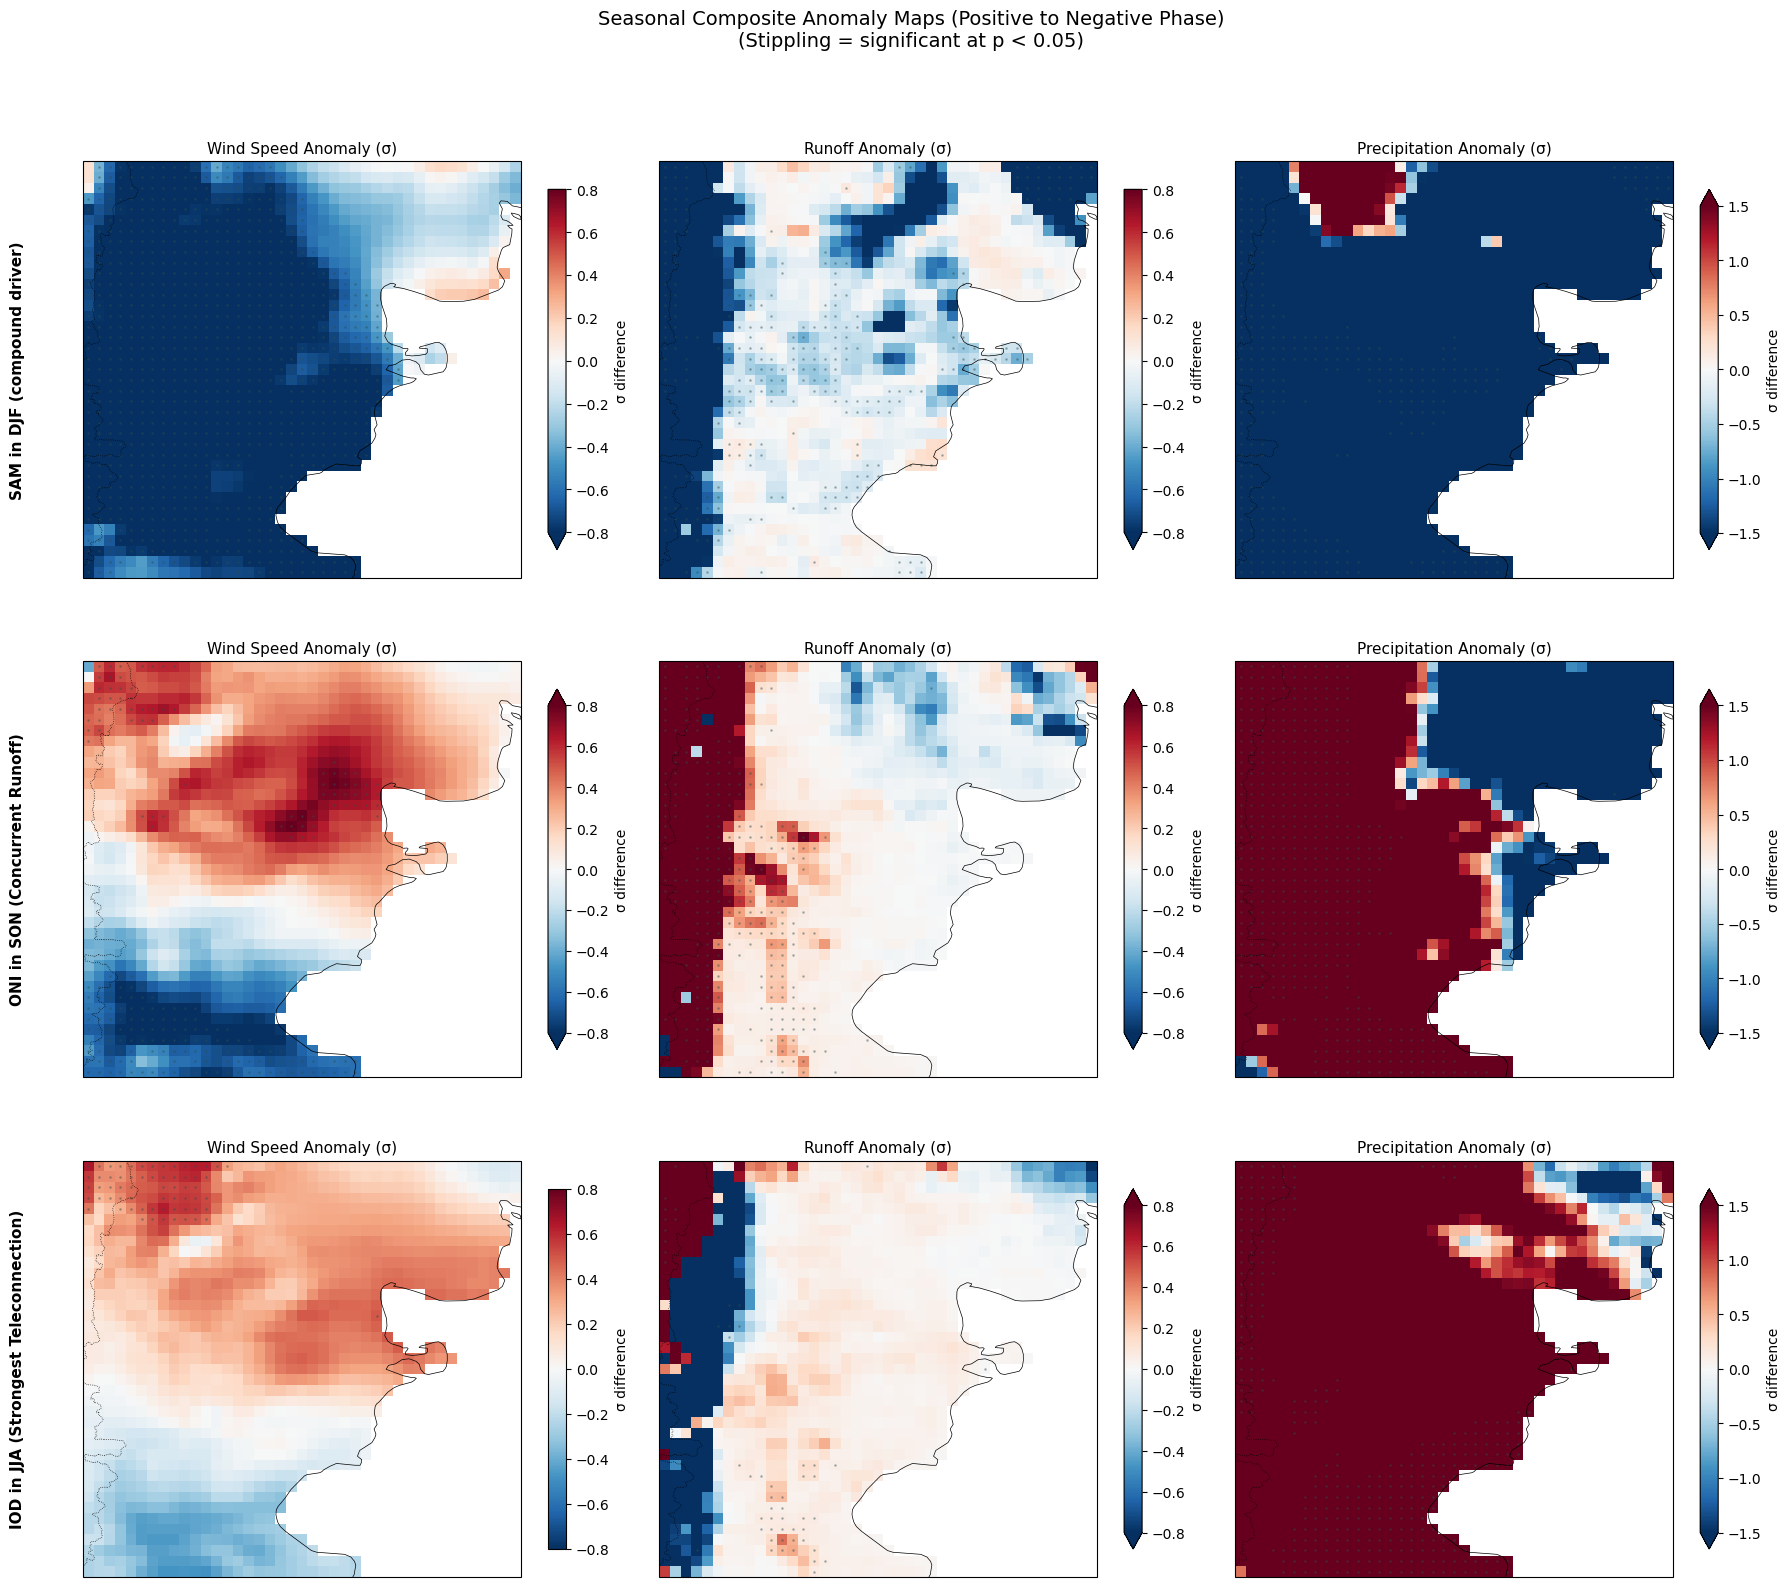

In [ ]:
fig, axes = plt.subplots(
    3, 3, figsize=(18, 16), subplot_kw={"projection": ccrs.PlateCarree()}
)

variables_to_map = [
    ("wind_speed", "Wind Speed Anomaly (σ)", 0.8),
    ("runoff", "Runoff Anomaly (σ)", 0.8),
    ("precipitation", "Precipitation Anomaly (σ)", 1.5),
]

for row, (key, comp_data) in enumerate(composites.items()):
    config = comp_data["config"]

    for col, (var, var_title, vmax) in enumerate(variables_to_map):
        ax = axes[row, col]

        diff = comp_data[f"{var}_diff"]
        sig = comp_data[f"{var}_sig"]

        # Plot difference field
        im = diff.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            vmin=-vmax,
            vmax=vmax,
            add_colorbar=True,
            cbar_kwargs={"shrink": 0.7, "label": "σ difference"},
        )

        # Stipple significant areas
        lons, lats = np.meshgrid(diff.longitude, diff.latitude)
        if sig.values.any():
            ax.scatter(
                lons[sig.values],
                lats[sig.values],
                color="darkslategrey",
                s=1,
                alpha=0.3,
                transform=ccrs.PlateCarree(),
            )

        ax.coastlines(resolution="50m", linewidth=0.5)
        ax.add_feature(
            cfeature.BORDERS,
            linestyle=":",
            linewidth=0.5,
        )
        ax.set_title(var_title, fontsize=11)

        if col == 0:
            ax.text(
                -0.15,
                0.5,
                config["title"],
                transform=ax.transAxes,
                fontsize=11,
                fontweight="bold",
                rotation=90,
                ha="center",
                va="center",
            )

plt.suptitle(
    "Seasonal Composite Anomaly Maps (Positive to Negative Phase)\n(Stippling = significant at p < 0.05)",
    fontsize=14,
)
plt.tight_layout()
plt.savefig(
    "../results/figures/seasonal_composite_maps.png", dpi=200, bbox_inches="tight"
)
plt.show()

## SAM Trend Analysis


SAM Trend: 0.021/year
Total change over record: +0.99
R²: 0.206, p: 0.0013

Running correlation trend: strengthening
    Mean correlation: -0.122
    Recent correlation: -0.116
    Early correlation: -0.076


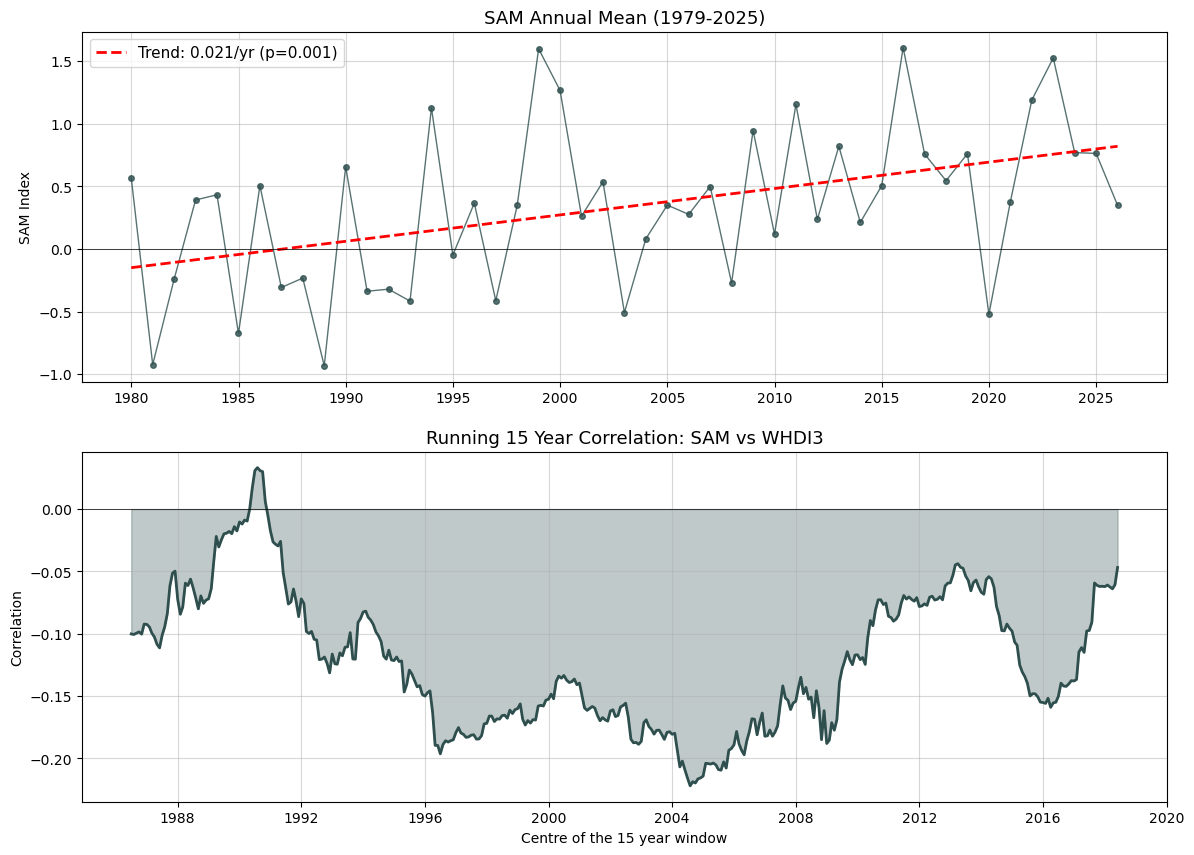

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# SAM timeseries with trend
ax = axes[0]
sam_annual = df["sam"].resample("YE").mean()
x = np.arange(len(sam_annual))
y = sam_annual.values
mask = ~np.isnan(y)

slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])
trend_line = intercept + slope * x

ax.plot(
    sam_annual.index,
    sam_annual.values,
    "o-",
    markersize=4,
    linewidth=1,
    color="darkslategrey",
    alpha=0.8,
)
ax.plot(
    sam_annual.index,
    trend_line[mask],
    "--",
    color="red",
    linewidth=2,
    label=f"Trend: {slope:.3f}/yr (p={p_value:.3f})",
)
ax.axhline(
    y=0,
    color="black",
    linewidth=0.5,
)
ax.set_title("SAM Annual Mean (1979-2025)", fontsize=13)
ax.set_ylabel("SAM Index")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.5)

# Total change
total_change = slope * len(sam_annual)
print(f"SAM Trend: {slope:.3f}/year")
print(f"Total change over record: {total_change:+.2f}")
print(f"R²: {r_value**2:.3f}, p: {p_value:.4f}")

# Running correlation between SAM and WHDI3 tests whether the teleconnection is stable over time
ax = axes[1]

window = 15 * 12

running_corr = []
running_dates = []

for i in range(0, len(df) - window):
    subset = df.iloc[i : i + window]
    sam_vals = subset["sam"].values
    whdi_vals = subset["whdi_3"].values

    valid = ~(np.isnan(sam_vals) | np.isnan(whdi_vals))
    if valid.sum() > 30:
        r, p = stats.pearsonr(sam_vals[valid], whdi_vals[valid])
        running_corr.append(r)
        running_dates.append(subset.index[window // 2])

ax.plot(
    running_dates,
    running_corr,
    linewidth=2,
    color="darkslategrey",
)
ax.axhline(
    y=0,
    color="black",
    linewidth=0.5,
)
ax.fill_between(
    running_dates,
    running_corr,
    0,
    alpha=0.3,
    color="darkslategrey",
)
ax.set_title("Running 15 Year Correlation: SAM vs WHDI3", fontsize=13)
ax.set_ylabel("Correlation")
ax.set_xlabel("Centre of the 15 year window")
ax.grid(True, alpha=0.5)

# Is the relationship strengthening?
corr_trend = stats.linregress(np.arange(len(running_corr)), running_corr)
trend_direction = "strengthening" if corr_trend.slope < 0 else "weakning"
print(f"\nRunning correlation trend: {trend_direction}")
print(f"    Mean correlation: {np.mean(running_corr):.3f}")
print(f"    Recent correlation: {np.mean(running_corr[-36:]):.3f}")
print(f"    Early correlation: {np.mean(running_corr[:36]):.3f}")

plt.tight_layout()
plt.savefig("../results/figures/sam_trend_analysis.png", dpi=200, bbox_inches="tight")
plt.show()